In [1]:
import kagglehub
adrianboguszewski_landcoverai_path = kagglehub.dataset_download('adrianboguszewski/landcoverai')

print('Data source import complete.')


100%|██████████| 1.43G/1.43G [00:16<00:00, 91.0MB/s]

Extracting files...


Data source import complete.


In [2]:
!pip install pennylane tifffile
!pip install qiskit qiskit-optimization qiskit-aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 67.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 17.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.9 MB/s eta 0:

In [3]:
import os, glob
base = adrianboguszewski_landcoverai_path
print("Base path:", base)
print("Top-level contents:", os.listdir(base))

image_dirs = glob.glob(os.path.join(base, "**", "images"), recursive=True)
mask_dirs  = glob.glob(os.path.join(base, "**", "masks"), recursive=True)
print("Image dirs:", image_dirs)
print("Mask dirs :", mask_dirs)

Base path: /root/.cache/kagglehub/datasets/adrianboguszewski/landcoverai/versions/2
Top-level contents: ['test.txt', 'val.txt', 'split.py', 'train.txt', 'masks', 'images']
Image dirs: ['/root/.cache/kagglehub/datasets/adrianboguszewski/landcoverai/versions/2/images']
Mask dirs : ['/root/.cache/kagglehub/datasets/adrianboguszewski/landcoverai/versions/2/masks']


In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [26]:

import os
import torch

import matplotlib.pyplot as plt

from torch.utils.data import Subset, DataLoader
import numpy as np


import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import pennylane as qml
import cv2
from skimage.metrics import structural_similarity as ssim
import os
import glob
import torch
from torch.utils.data import Dataset,DataLoader
from PIL import Image
import numpy as np

class LandCoverDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.images = sorted(glob.glob(os.path.join(image_dir, "*.tif")))
        self.masks = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))

        assert len(self.images) == len(self.masks), "Mismatch between images and masks"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx])

        crop_size = 256
        x = np.random.randint(0, img.width - crop_size)
        y = np.random.randint(0, img.height - crop_size)
        img = img.crop((x, y, x+crop_size, y+crop_size))
        mask = mask.crop((x, y, x+crop_size, y+crop_size))

        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask)

        mask = (mask == 2).astype(np.float32)

        img = torch.tensor(img).permute(2, 0, 1)
        mask = torch.tensor(mask).unsqueeze(0)

        return img, mask

def compute_iou(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

def extract_bboxes(mask, threshold=0.3):
    H, W = mask.shape

    mask_bin = (mask > threshold).astype(np.uint8) * 255

    k = max(3, int(min(H, W) * 0.03))
    kernel = np.ones((k, k), np.uint8)

    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes, scores = [], []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        if w * h < 100:
            continue

        region = mask[y:y+h, x:x+w]
        score = float(np.mean(region))

        score *= (w * h) / (H * W)

        boxes.append([x, y, x + w, y + h])
        scores.append(score)

    return boxes, scores

def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

n_qubits = 8
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i] * np.pi, wires=i)

    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc_reduce = nn.Linear(32, n_qubits)

        self.weights = nn.Parameter(0.01 * torch.randn(3, n_qubits, 3))

    def forward(self, x):
        q_in = torch.tanh(self.fc_reduce(x))

        q_out = []
        for i in range(q_in.shape[0]):
            out = quantum_circuit(q_in[i], self.weights)
            q_out.append(torch.stack(out) if isinstance(out, list) else out)

        return torch.stack(q_out).float().to(x.device)

# -------------------------
# 2. ATTENTION U-NET BACKBONE[cite: 2]
# -------------------------
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g, F_int, kernel_size=1)
        self.W_x = nn.Conv2d(F_l, F_int, kernel_size=1)
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.Sigmoid() # Attention map alpha[cite: 2]
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.psi(g1 + x1)
        return x * psi

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(4, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.att1 = AttentionGate(F_g=64, F_l=32, F_int=32)
        self.dec1 = nn.Conv2d(96, 32, 3, padding=1)
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        s1 = F.relu(self.enc1(x))
        p1 = self.pool(s1)
        s2 = F.relu(self.enc2(p1))
        d1 = self.up1(s2)
        a1 = self.att1(g=d1, x=s1)
        c1 = torch.cat([d1, a1], dim=1)
        res = F.relu(self.dec1(c1))
        return torch.sigmoid(self.final(res))

# -------------------------
# 3. QAQS-C QUBO SUPPRESSION
# -------------------------
def build_qubo_qaqs_c(boxes, scores, w_conf=1.0, w_iou=2.0, w_dist=0.5):
    n = len(boxes)
    Q = np.zeros((n, n))

    for i in range(n):
        Q[i, i] = -w_conf * (scores[i] ** 2)

        for j in range(i + 1, n):
            iou = compute_iou(boxes[i], boxes[j])
            b1_center = [(boxes[i][0]+boxes[i][2])/2, (boxes[i][1]+boxes[i][3])/2]
            b2_center = [(boxes[j][0]+boxes[j][2])/2, (boxes[j][1]+boxes[j][3])/2]
            dist = np.sqrt((b1_center[0]-b2_center[0])**2 + (b1_center[1]-b2_center[1])**2)
            penalty = (w_iou * iou) + (w_dist * np.exp(-dist / 25.0))

            Q[i, j] = Q[j, i] = penalty * scores[i] * scores[j]

    return Q
# -------------------------
# 4. TRAINING & INFERENCE[cite: 1, 2]
# -------------------------
class HybridModel(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.quantum_bottleneck = QuantumBottleneck()
        self.fc_quantum_out = nn.Linear(n_qubits, 32)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU()
        )
        self.final = nn.Conv2d(16, num_classes, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(F.max_pool2d(s1, 2))

        pooled = F.adaptive_avg_pool2d(s2, (1, 1)).view(x.size(0), -1)
        q_out = self.quantum_bottleneck(pooled)
        q_feat = self.fc_quantum_out(q_out).view(x.size(0), 32, 1, 1)

        q_context = q_feat.expand(-1, -1, s2.size(2), s2.size(3))

        combined = torch.cat([s2, q_context], dim=1)
        up = F.interpolate(combined, scale_factor=2, mode='bilinear', align_corners=True)
        out = self.dec1(up)
        return torch.sigmoid(self.final(out))


dataset = LandCoverDataset(
    '/root/.cache/kagglehub/datasets/adrianboguszewski/landcoverai/versions/2/images',
    '/root/.cache/kagglehub/datasets/adrianboguszewski/landcoverai/versions/2/masks'
)

dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

def visualize_batch(imgs, masks, preds, epoch):
    imgs = imgs.cpu()
    masks = masks.cpu()
    preds = preds.detach().cpu()

    img = imgs[0].permute(1, 2, 0).numpy()
    gt = masks[0, 0].numpy()
    pred = preds[0, 0].numpy()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].imshow(img)
    axs[0].set_title(f"Input (Epoch {epoch})")
    axs[0].axis("off")

    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("Ground Truth")
    axs[1].axis("off")

    axs[2].imshow(pred, cmap="gray")
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

def train_model(model, loader, epochs=10, checkpoint_dir="/content/checkpoints"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, "latest.pt")

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4
    )

    start_epoch = 0

    if os.path.exists(checkpoint_path):
        print("Loading checkpoint...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resumed from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs):
        model.train()
        total_loss = 0

        for i, (imgs, masks) in enumerate(loader):
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            masks_res = F.interpolate(masks, size=preds.shape[2:], mode='nearest')

            bce = F.binary_cross_entropy(preds, masks_res, weight=(masks_res * 1 + 1))
            dice = dice_loss(preds, masks_res)
            loss = bce + dice

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()


            if i == 0 and (epoch % 2 == 0):
                visualize_batch(imgs, masks_res, preds, epoch)

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "loss": avg_loss
        }, checkpoint_path)

        print(f"Checkpoint saved at epoch {epoch}")



In [9]:
model = HybridModel()

for param in model.quantum_bottleneck.parameters():
    param.requires_grad = True

print(model.quantum_bottleneck.weights.requires_grad)


train_model(model,dataloader,epochs = 124)

True
Loading checkpoint...
Resumed from epoch 124


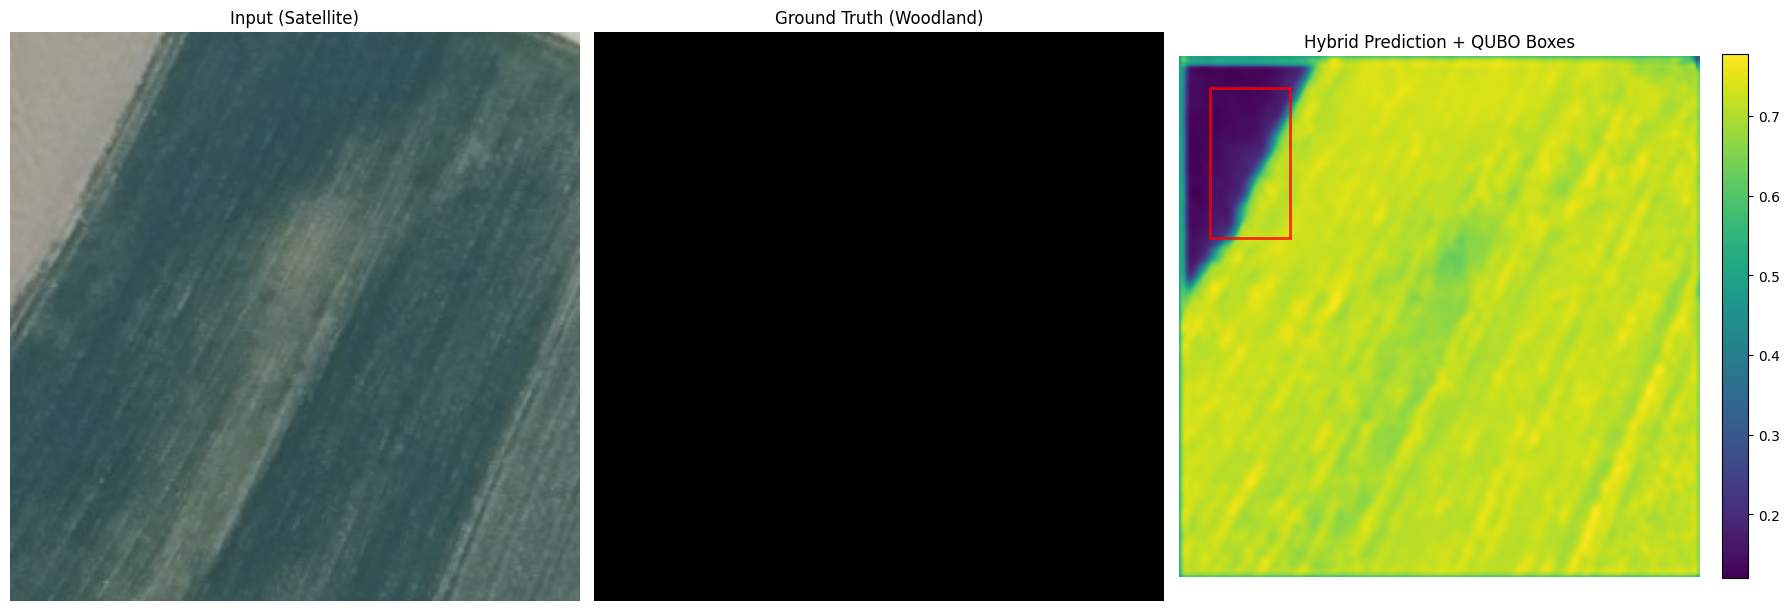

Detected 1 Woodland clusters.


In [10]:

import matplotlib.patches as patches
def solve_qubo_annealing(Q, steps=1000):
    n = len(Q)
    current_state = np.random.randint(2, size=n)

    def get_energy(state):
        return state @ Q @ state

    current_energy = get_energy(current_state)

    for T in np.linspace(10, 0.1, steps):
        idx = np.random.randint(n)
        next_state = current_state.copy()
        next_state[idx] = 1 - next_state[idx]
        next_energy = get_energy(next_state)
        delta_e = next_energy - current_energy

        if delta_e < 0 or np.random.rand() < np.exp(-delta_e / T):
            current_state = next_state
            current_energy = next_energy

    return np.where(current_state == 1)[0]

def run_inference(model, img_tensor, img_np, threshold=0.4):
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        pred = model(img_tensor.to(device))
        pred_mask = pred.cpu().numpy()[0, 0]

    inverted_mask = 1.0 - pred_mask
    margin = 15
    inverted_mask[:margin, :] = 0
    inverted_mask[-margin:, :] = 0
    inverted_mask[:, :margin] = 0
    inverted_mask[:, -margin:] = 0

    p_min, p_max = pred_mask.min(), pred_mask.max()
    if p_max > p_min:
        pred_mask = (pred_mask - p_min) / (p_max - p_min)
    raw_boxes, raw_scores = extract_bboxes(inverted_mask, threshold=0.75)

    if not raw_boxes:
        return []

    # --- STAGE 4: QUBO OPTIMIZATION (Paper 2) ---
    Q = build_qubo_qaqs_c(raw_boxes, raw_scores, w_iou=3.5, w_dist=0.4)
    selected_indices = solve_qubo_annealing(Q, steps=2500)

    return [raw_boxes[i] for i in selected_indices]


import random

random_idx = random.randint(0, len(dataset) - 1)
img, mask = dataset[random_idx]

sample_img = img.unsqueeze(0).to(device)
sample_np = img.permute(1, 2, 0).numpy()

model.eval()
boxes = run_inference(model, sample_img, sample_np)
model.eval()
boxes = run_inference(model, sample_img, sample_np)

with torch.no_grad():
    pred_mask = model(sample_img.to(device)).cpu().numpy()[0, 0]

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(sample_np)
axs[0].set_title("Input (Satellite)")
axs[0].axis("off")

axs[1].imshow(mask.squeeze(), cmap="gray")
axs[1].set_title("Ground Truth (Woodland)")
axs[1].axis("off")

im = axs[2].imshow(pred_mask, cmap="viridis")
axs[2].set_title("Hybrid Prediction + QUBO Boxes")
plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)

for box in boxes:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none', alpha=0.8
    )
    axs[2].add_patch(rect)

axs[2].axis("off")
plt.tight_layout()
plt.show()

print(f"Detected {len(boxes)} Woodland clusters.")

In [11]:

import numpy as np

try:
    from qiskit_optimization import QuadraticProgram
    from qiskit_optimization.algorithms import MinimumEigenOptimizer
    from qiskit_optimization.minimum_eigensolvers import QAOA
    from qiskit_optimization.optimizers import COBYLA
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_aer import AerSimulator
    from qiskit_aer.primitives import SamplerV2
    QISKIT_AVAILABLE = True
except ImportError as _e:
    QISKIT_AVAILABLE = False
    _IMPORT_ERR = _e


# QUBO -> QuadraticProgram conversion
def _qubo_to_quadratic_program(Q):
    """
    Convert a symmetric numpy QUBO matrix `Q` (minimize x^T Q x) into a
    qiskit_optimization.QuadraticProgram.

    IMPORTANT: x^T Q x = sum_i Q[i,i] x_i  +  sum_{i<j} (Q[i,j] + Q[j,i]) x_i x_j
    For symmetric Q, the cross-term coefficient is 2*Q[i,j]. The brief's snippet
    omits this factor of 2; this implementation fixes it.
    """
    n = len(Q)
    qp = QuadraticProgram()
    for i in range(n):
        qp.binary_var(name=f"x{i}")

    linear = {f"x{i}": float(Q[i, i]) for i in range(n)}
    quadratic = {}
    for i in range(n):
        for j in range(i + 1, n):
            coeff = float(Q[i, j] + Q[j, i])  # = 2*Q[i,j] when symmetric
            if abs(coeff) > 1e-12:
                quadratic[(f"x{i}", f"x{j}")] = coeff

    qp.minimize(linear=linear, quadratic=quadratic)
    return qp


def solve_qubo_qaoa(
    Q,
    reps=3,
    maxiter=100,
    shots=1024,
    fallback_n=15,
    seed=42,
    fallback_fn=None,
    verbose=False,
):
    """
    Solve a QUBO using QAOA on the Qiskit AerSimulator.

    Args:
        Q: (n, n) symmetric numpy array. Minimizes x^T Q x.
           Diagonal = linear coefficients, off-diagonal = quadratic.
        reps: QAOA depth p (more = better quality, slower). 3 is a good default.
        maxiter: COBYLA classical-optimizer iteration cap.
        shots: Sampler shots per circuit evaluation.
        fallback_n: If n exceeds this, fall back to `fallback_fn`.
                    Empirically QAOA-on-Aer stays sub-3s up to n=14.
        seed: Sampler seed for reproducibility (use None for randomness).
        fallback_fn: Function to call for n > fallback_n. Should accept Q
                     and return indices. Defaults to solve_qubo_annealing
                     if it's in scope; otherwise raises.
        verbose: Print timing and result info.

    Returns:
        np.ndarray of indices selected (x_i == 1).

    Notes:
        QAOA is approximate. For small n it does not always reach the exact
        ground state — gaps of a few percent are normal. For box selection
        this is acceptable: near-optimal box subsets still produce sensible
        non-overlapping picks. Raise `reps` or `maxiter` if quality matters.
    """
    n = len(Q)

    if n == 0:
        return np.array([], dtype=int)
    if n == 1:
        return np.array([0]) if Q[0, 0] < 0 else np.array([], dtype=int)

    if n > fallback_n:
        if fallback_fn is None:
            fallback_fn = globals().get("solve_qubo_annealing")
        if fallback_fn is None:
            raise RuntimeError(
                f"n={n} exceeds fallback_n={fallback_n} but no fallback_fn "
                f"was provided and solve_qubo_annealing is not in scope."
            )
        if verbose:
            print(f"[QAOA] n={n} > {fallback_n}, falling back to {fallback_fn.__name__}")
        return fallback_fn(Q)

    if not QISKIT_AVAILABLE:
        raise ImportError(
            f"Qiskit not available ({_IMPORT_ERR}). Run:\n"
            f"  !pip install qiskit qiskit-optimization qiskit-aer"
        )

    qp = _qubo_to_quadratic_program(Q)

    backend = AerSimulator()
    pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
    sampler = SamplerV2(seed=seed, default_shots=shots)
    qaoa = QAOA(
        sampler=sampler,
        optimizer=COBYLA(maxiter=maxiter),
        reps=reps,
        pass_manager=pass_manager,
    )

    meo = MinimumEigenOptimizer(qaoa)
    if verbose:
        import time
        t0 = time.time()
    result = meo.solve(qp)
    if verbose:
        print(f"[QAOA] n={n}, reps={reps}, fval={result.fval:.4f}, "
              f"time={time.time()-t0:.2f}s")

    x = np.array(result.x, dtype=float)
    return np.where(x > 0.5)[0]


def solve_qubo(Q, method="annealing", **kwargs):

    if method == "qaoa":
        return solve_qubo_qaoa(Q, **kwargs)
    elif method == "annealing":
        return solve_qubo_annealing(Q, **kwargs)
    else:
        raise ValueError(f"Unknown method: {method!r}")



def run_inference(model, img_tensor, img_np, threshold=0.4, method="annealing",
                  qaoa_kwargs=None):
    """
    Run hybrid model + post-processing + QUBO box selection.

    Args:
        model:      trained HybridModel
        img_tensor: (1, 3, H, W) tensor on any device
        img_np:     (H, W, 3) numpy image (kept for signature compat)
        threshold:  kept for signature compat; actual bbox threshold is 0.75 below
        method:     "annealing" (default) or "qaoa"
        qaoa_kwargs: dict of extra args for solve_qubo_qaoa (e.g. {"reps":4})
    """
    import torch
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        pred = model(img_tensor.to(device))
        pred_mask = pred.cpu().numpy()[0, 0]

    inverted_mask = 1.0 - pred_mask
    margin = 15
    inverted_mask[:margin, :] = 0
    inverted_mask[-margin:, :] = 0
    inverted_mask[:, :margin] = 0
    inverted_mask[:, -margin:] = 0

    p_min, p_max = pred_mask.min(), pred_mask.max()
    if p_max > p_min:
        pred_mask = (pred_mask - p_min) / (p_max - p_min)

    raw_boxes, raw_scores = extract_bboxes(inverted_mask, threshold=0.75)
    if not raw_boxes:
        return []

    Q = build_qubo_qaqs_c(raw_boxes, raw_scores, w_iou=3.5, w_dist=0.4)

    if method == "qaoa":
        selected_indices = solve_qubo_qaoa(Q, **(qaoa_kwargs or {}))
    else:
        selected_indices = solve_qubo_annealing(Q, steps=2500)

    return [raw_boxes[i] for i in selected_indices]



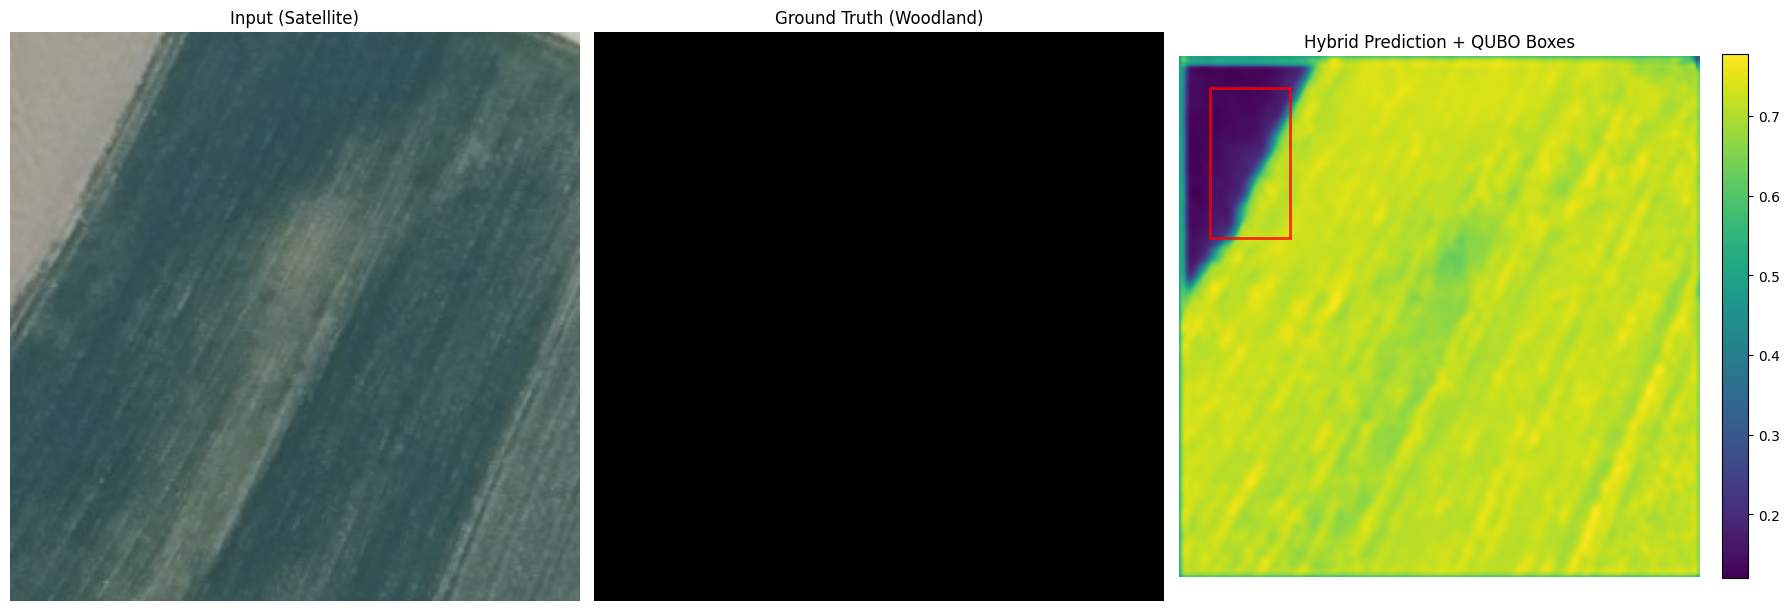

Detected 1 Woodland clusters.


In [12]:

boxes = run_inference(model, sample_img, sample_np, method="qaoa")

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(sample_np)
axs[0].set_title("Input (Satellite)")
axs[0].axis("off")

axs[1].imshow(mask.squeeze(), cmap="gray")
axs[1].set_title("Ground Truth (Woodland)")
axs[1].axis("off")

im = axs[2].imshow(pred_mask, cmap="viridis")
axs[2].set_title("Hybrid Prediction + QUBO Boxes")
plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)

for box in boxes:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='red', facecolor='none', alpha=0.8
    )
    axs[2].add_patch(rect)

axs[2].axis("off")
plt.tight_layout()
plt.show()

print(f"Detected {len(boxes)} Woodland clusters.")



# Diagnosis Runs:
> Following cells contains some diagnosis runs to detect the issues related to bounded boxes detection

---


In [ ]:
import numpy as np
import torch

model.eval()
device = next(model.parameters()).device

with torch.no_grad():
    pred = model(sample_img.to(device))
    pred_mask = pred.cpu().numpy()[0, 0]

print(f"Pred mask  : min={pred_mask.min():.3f} max={pred_mask.max():.3f} "
      f"mean={pred_mask.mean():.3f}")
print(f"Pred > 0.5 : {(pred_mask > 0.5).sum()} pixels (woodland predicted)")
print(f"GT mask    : {int(mask.sum().item())} pixels are actually woodland")

inverted_mask = 1.0 - pred_mask
margin = 15
inverted_mask[:margin, :] = 0
inverted_mask[-margin:, :] = 0
inverted_mask[:, :margin] = 0
inverted_mask[:, -margin:] = 0
print(f"Inverted   : min={inverted_mask.min():.3f} max={inverted_mask.max():.3f} "
      f"mean={inverted_mask.mean():.3f}")
print(f"Inv > 0.75 : {(inverted_mask > 0.75).sum()} pixels above threshold")

raw_boxes, raw_scores = extract_bboxes(inverted_mask, threshold=0.75)
print(f"Raw boxes  : {len(raw_boxes)} (after morphology + area>100 filter)")
print(f"Scores     : {raw_scores}")

Pred mask  : min=0.440 max=0.611 mean=0.488
Pred > 0.5 : 26117 pixels (woodland predicted)
GT mask    : 14073 pixels are actually woodland
Inverted   : min=0.000 max=0.560 mean=0.398
Inv > 0.75 : 0 pixels above threshold
Raw boxes  : 0 (after morphology + area>100 filter)
Scores     : []


In [ ]:
boxes_no_invert, scores_no_invert = extract_bboxes(pred_mask, threshold=0.5)
print(f"Without inversion, threshold 0.5: {len(boxes_no_invert)} boxes")

Without inversion, threshold 0.5: 5 boxes


In [ ]:
boxes_a = run_inference(model, sample_img, sample_np, method="annealing")
boxes_q = run_inference(model, sample_img, sample_np, method="qaoa")
print(f"Annealing: {len(boxes_a)}  |  QAOA: {len(boxes_q)}")

Annealing: 0  |  QAOA: 0


In [ ]:
import numpy as np

model.eval()
device = next(model.parameters()).device
with torch.no_grad():
    pred_mask = model(sample_img.to(device)).cpu().numpy()[0, 0]

threshold = 0.52
raw_boxes, raw_scores = extract_bboxes(pred_mask, threshold=threshold)
print(f"Boxes at threshold {threshold}: {len(raw_boxes)}")

if raw_boxes:
    Q = build_qubo_qaqs_c(raw_boxes, raw_scores, w_iou=3.5, w_dist=0.4)
    print(f"QUBO matrix shape: {Q.shape}")

    selected_anneal = solve_qubo_annealing(Q, steps=2500)
    selected_qaoa   = solve_qubo_qaoa(Q, verbose=True)

    print(f"Annealing kept: {selected_anneal}")
    print(f"QAOA kept     : {selected_qaoa}")

Boxes at threshold 0.52: 9
QUBO matrix shape: (9, 9)
[QAOA] n=9, reps=3, fval=-0.0099, time=1.99s
Annealing kept: [1 4 5]
QAOA kept     : [1 3 8]


## Final Inference Override:
> Following is the final interference override with custom thresholds and some sample runs

Plotting is following by the interfernce
<b>

In [15]:
def run_inference(model, img_tensor, img_np, threshold=0.5, method="annealing",
                  qaoa_kwargs=None, use_stretch=True):
    """
    threshold:    applied to (optionally stretched) pred_mask. 0.5 is a sensible
                  default; with this weak model + stretching, 0.5 captures the
                  brighter half of the prediction.
    use_stretch:  rescale pred_mask to full [0,1] range before thresholding.
                  Helps weak models whose raw output is squashed near 0.5.
    method:       "annealing" or "qaoa".
    qaoa_kwargs:  e.g. {"reps": 3, "maxiter": 100, "verbose": True}
    """
    import torch
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        pred_mask = model(img_tensor.to(device)).cpu().numpy()[0, 0]

    if use_stretch:
        p_min, p_max = pred_mask.min(), pred_mask.max()
        if p_max > p_min:
            pred_mask = (pred_mask - p_min) / (p_max - p_min)

    margin = 15
    pred_mask[:margin, :] = 0
    pred_mask[-margin:, :] = 0
    pred_mask[:, :margin] = 0
    pred_mask[:, -margin:] = 0

    raw_boxes, raw_scores = extract_bboxes(pred_mask, threshold=threshold)
    if not raw_boxes:
        return [], pred_mask

    Q = build_qubo_qaqs_c(raw_boxes, raw_scores, w_iou=3.5, w_dist=0.4)
    if method == "qaoa":
        selected = solve_qubo_qaoa(Q, **(qaoa_kwargs or {}))
    else:
        selected = solve_qubo_annealing(Q, steps=2500)

    return [raw_boxes[i] for i in selected], pred_mask

In [16]:
def infere_and_plot():

  import random
  import matplotlib.patches as patches
  import matplotlib.pyplot as plt

  random_idx = random.randint(0, len(dataset) - 1)
  img, mask = dataset[random_idx]
  sample_img = img.unsqueeze(0).to(device)
  sample_np = img.permute(1, 2, 0).numpy()

  boxes_anneal, pred_mask = run_inference(model, sample_img, sample_np,
                                          method="annealing", threshold=0.5)
  boxes_qaoa, _ = run_inference(model, sample_img, sample_np,
                                method="qaoa", threshold=0.5,
                                qaoa_kwargs={"verbose": True})

  fig, axs = plt.subplots(1, 4, figsize=(22, 5))

  axs[0].imshow(sample_np);             axs[0].set_title("Input");        axs[0].axis("off")
  axs[1].imshow(mask.squeeze(), cmap="gray"); axs[1].set_title("Ground Truth"); axs[1].axis("off")

  for ax, boxes, title in [(axs[2], boxes_anneal, f"SA: {len(boxes_anneal)} boxes"),
                            (axs[3], boxes_qaoa,   f"QAOA: {len(boxes_qaoa)} boxes")]:
      ax.imshow(pred_mask, cmap="viridis")
      ax.set_title(title)
      for x1, y1, x2, y2 in boxes:
          ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor='red', facecolor='none'))
      ax.axis("off")

  plt.tight_layout()
  plt.show()

  print(f"Annealing kept {len(boxes_anneal)} boxes")
  print(f"QAOA      kept {len(boxes_qaoa)} boxes")

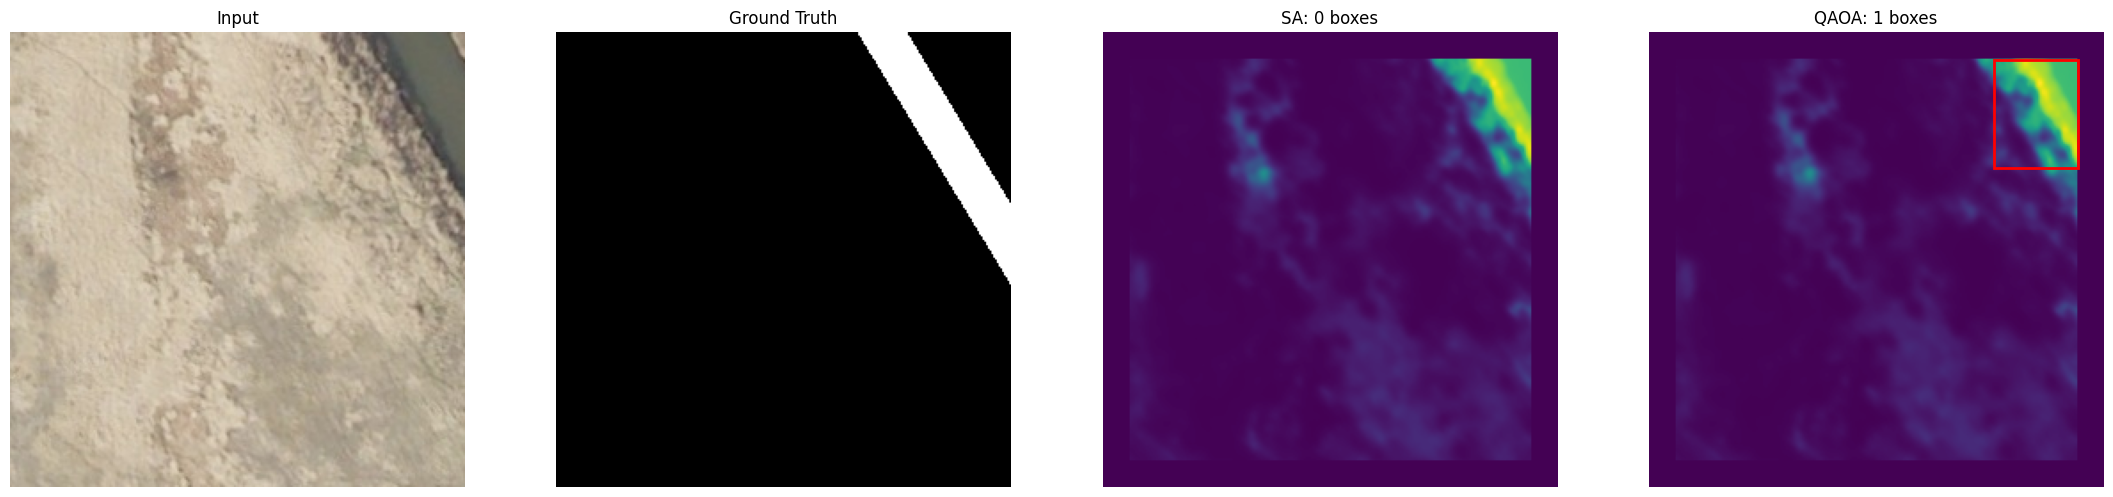

Annealing kept 0 boxes
QAOA      kept 1 boxes


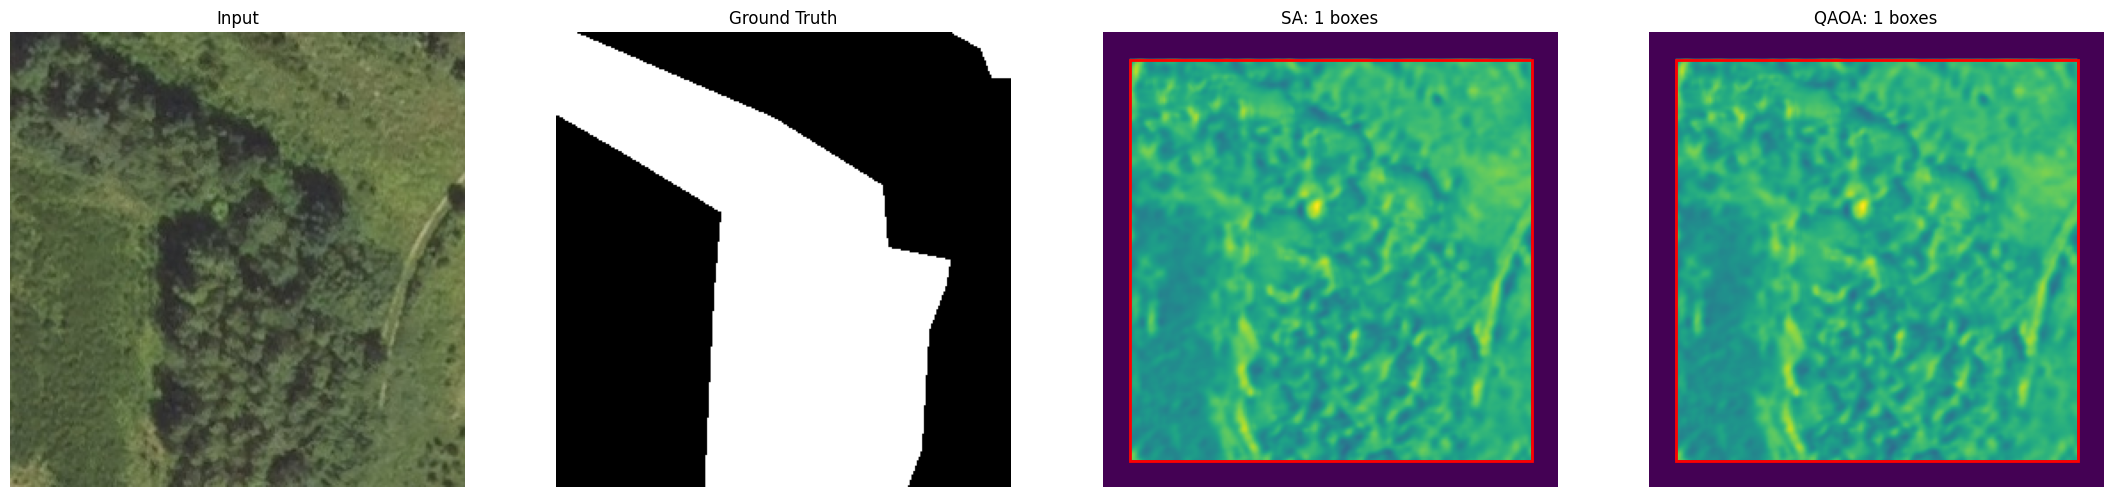

Annealing kept 1 boxes
QAOA      kept 1 boxes
[QAOA] n=6, reps=3, fval=-0.1732, time=1.28s


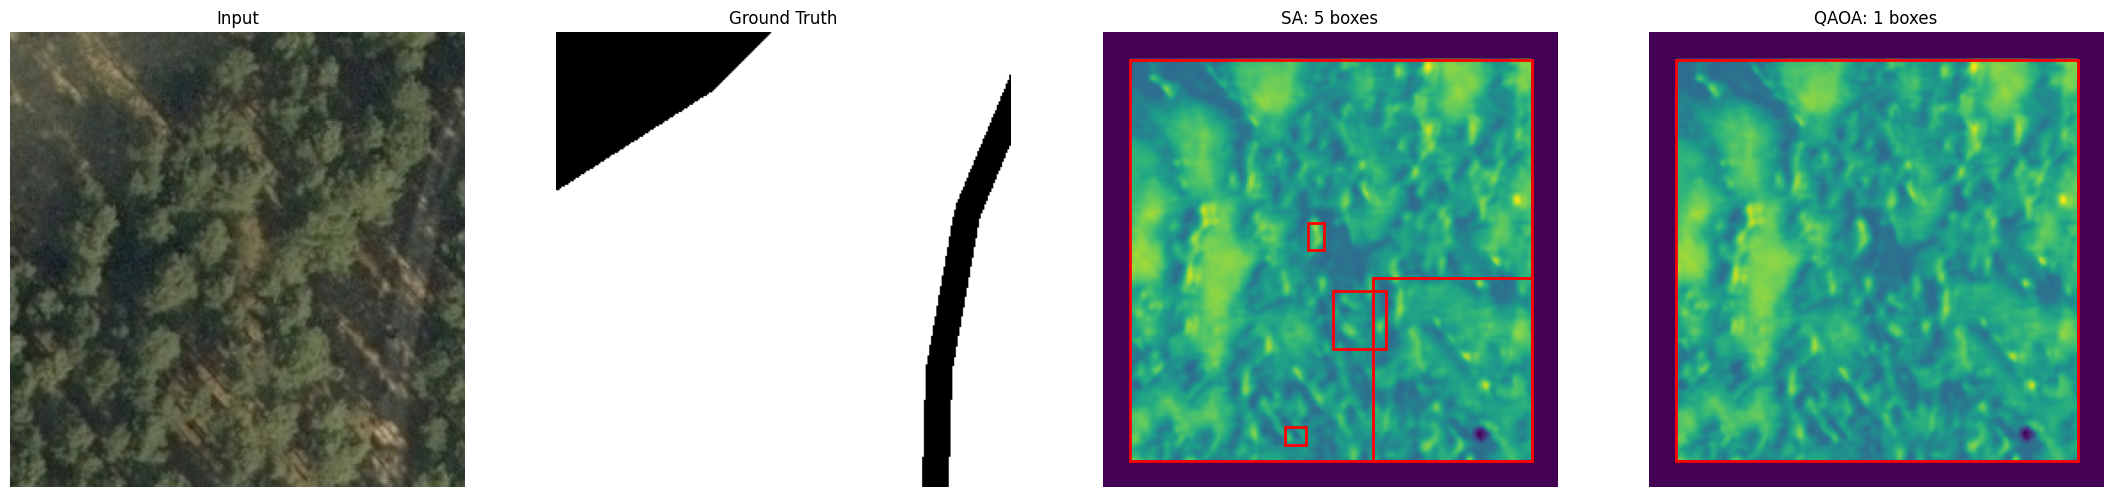

Annealing kept 5 boxes
QAOA      kept 1 boxes


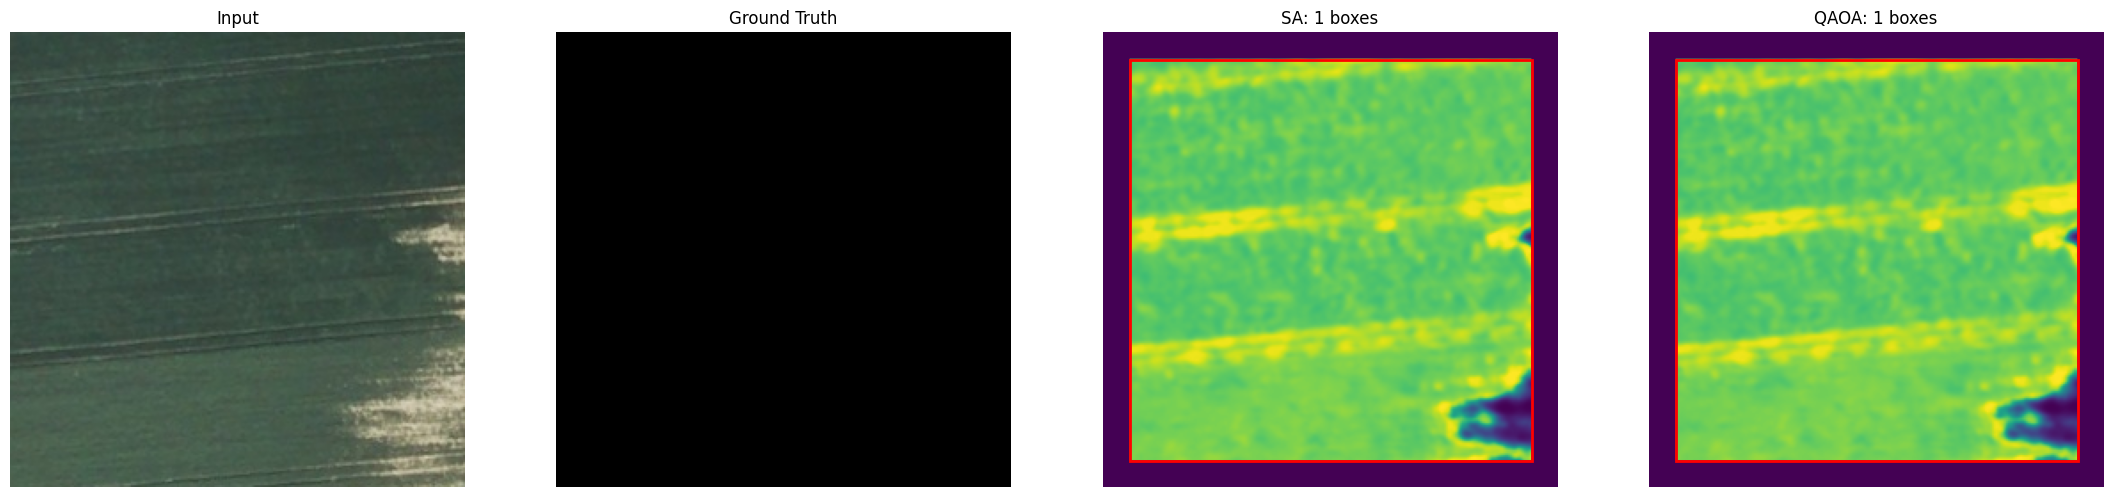

Annealing kept 1 boxes
QAOA      kept 1 boxes


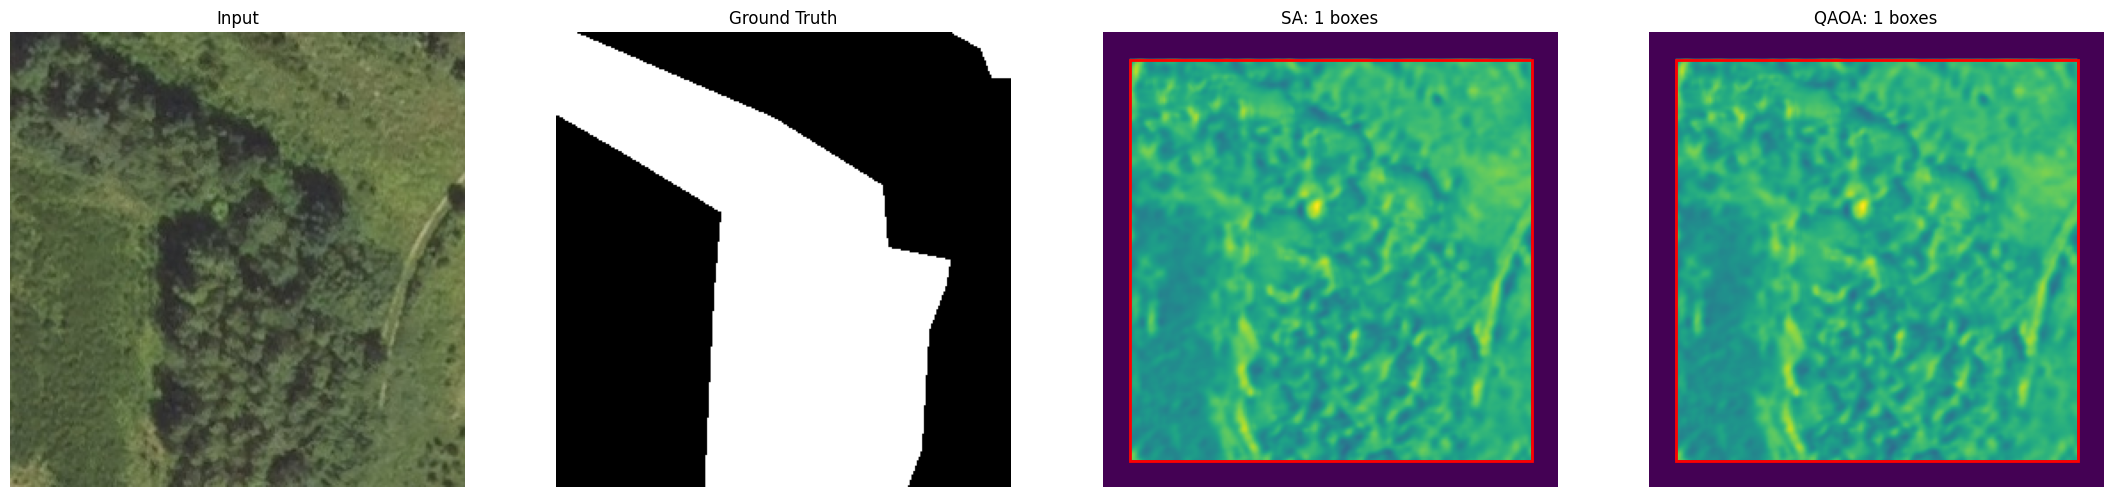

Annealing kept 1 boxes
QAOA      kept 1 boxes
[QAOA] n=3, reps=3, fval=-0.0205, time=0.86s


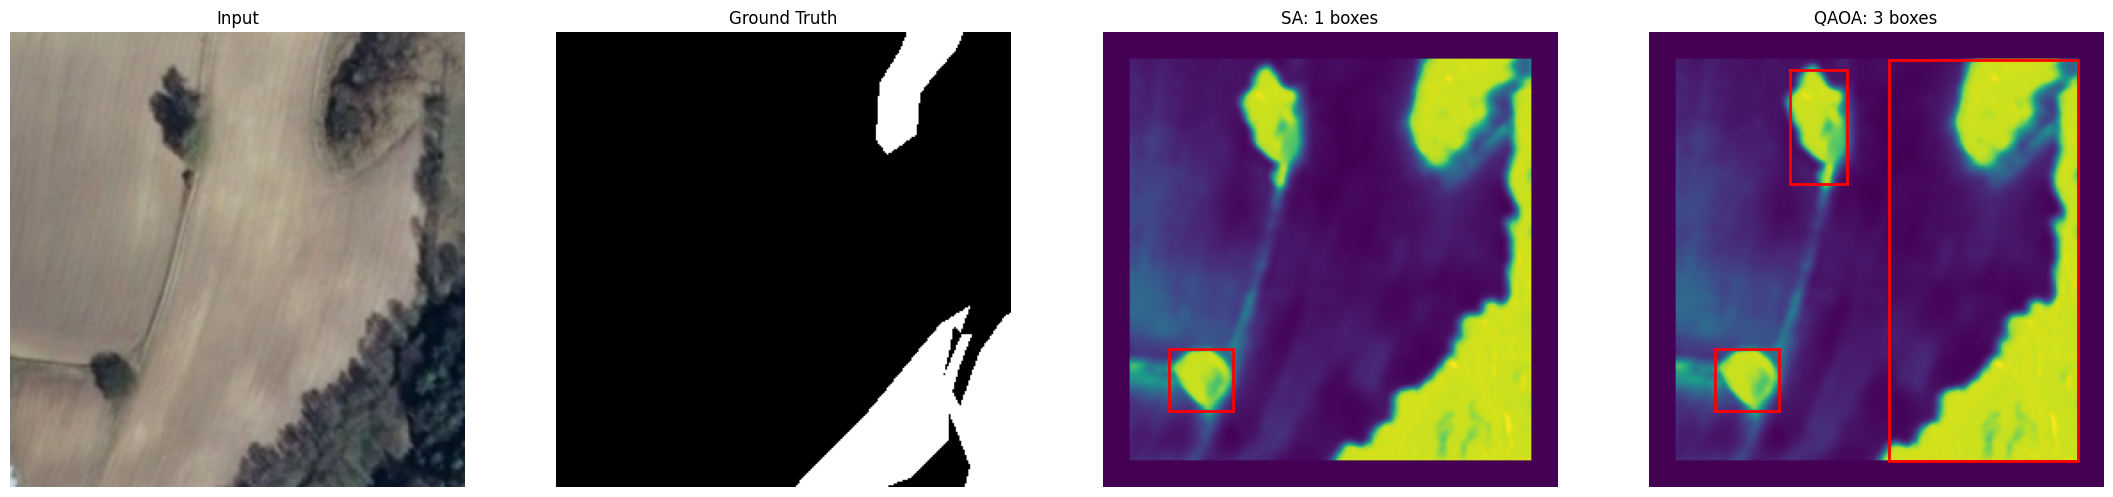

Annealing kept 1 boxes
QAOA      kept 3 boxes
[QAOA] n=3, reps=3, fval=-0.0001, time=0.20s


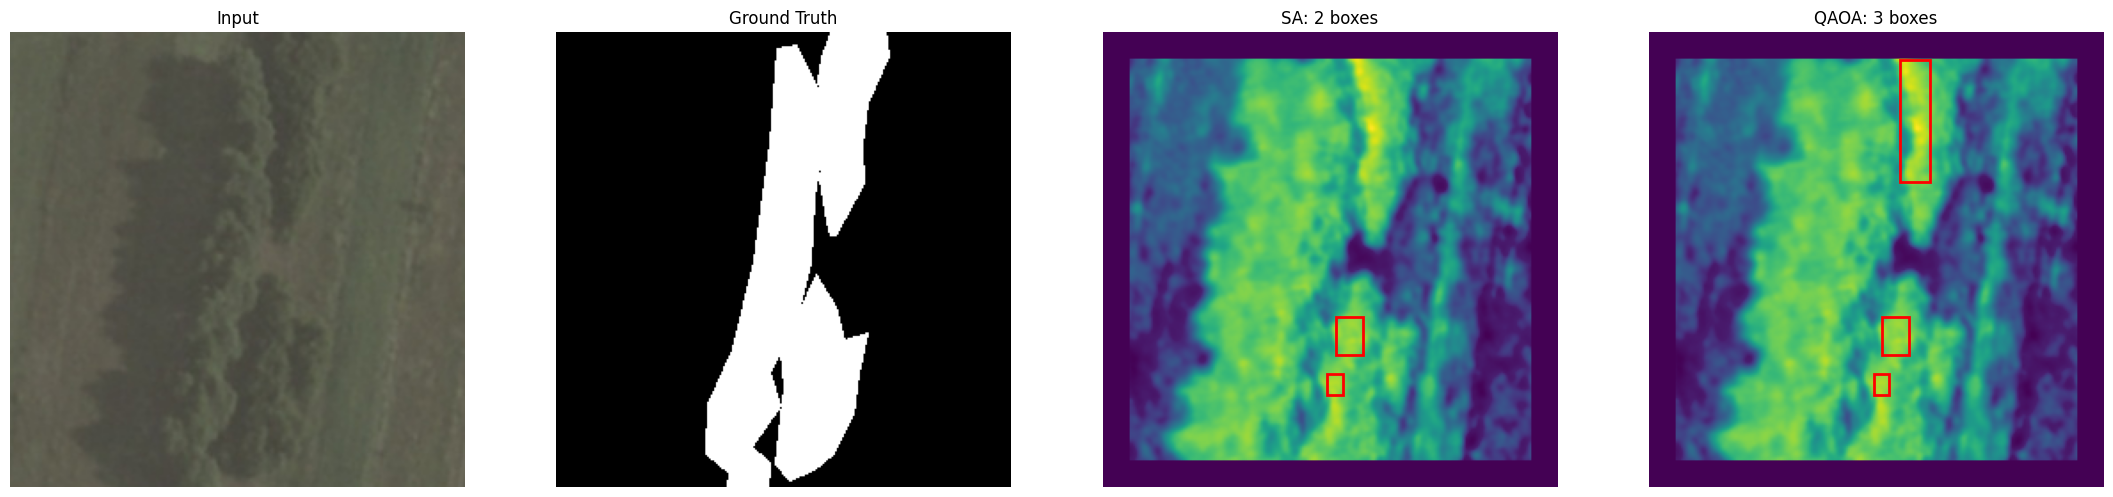

Annealing kept 2 boxes
QAOA      kept 3 boxes


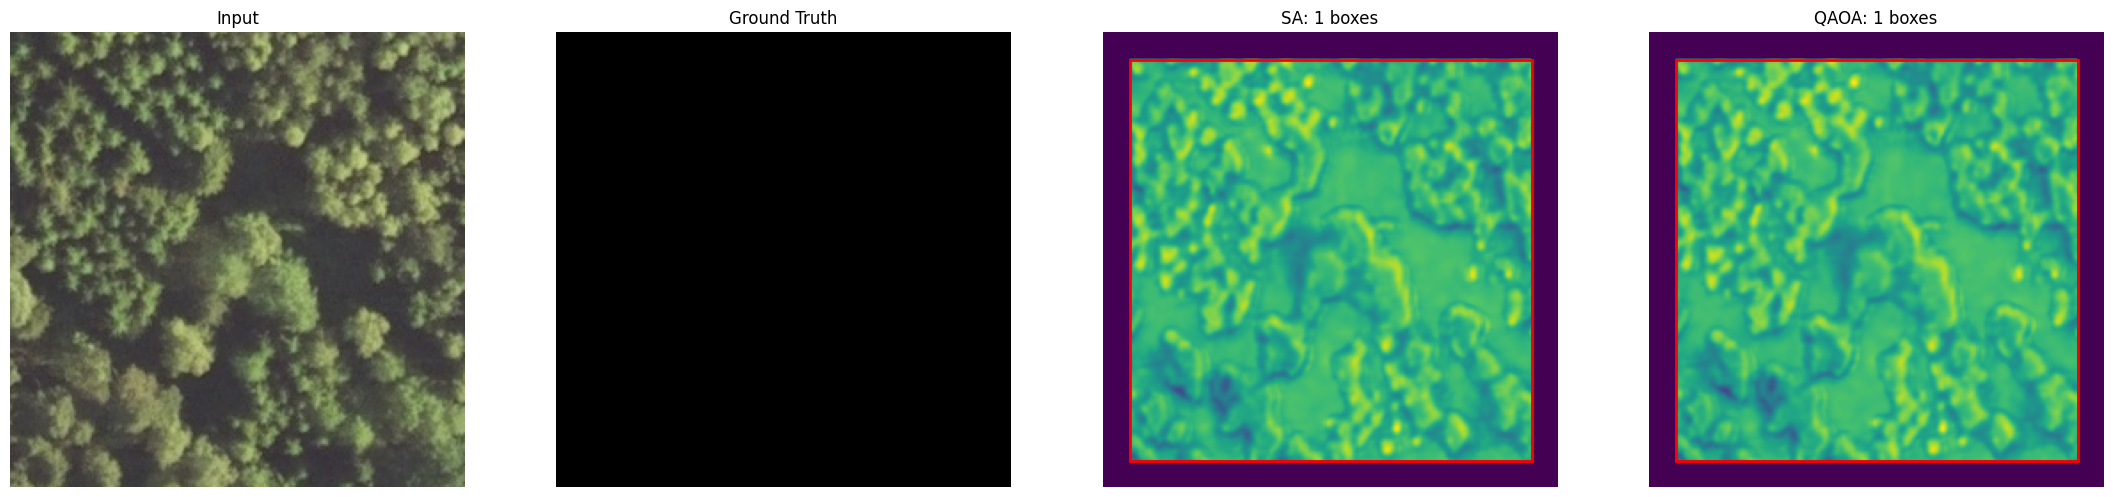

Annealing kept 1 boxes
QAOA      kept 1 boxes


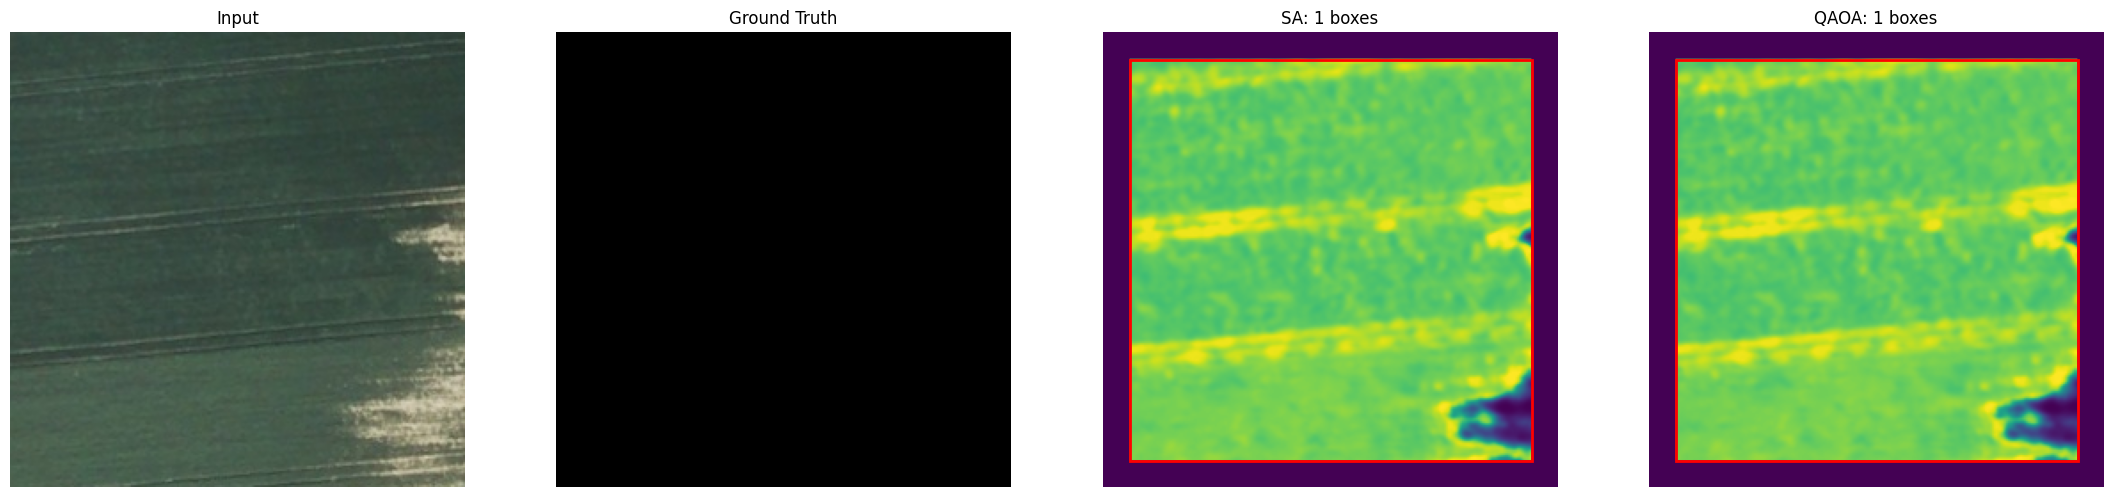

Annealing kept 1 boxes
QAOA      kept 1 boxes


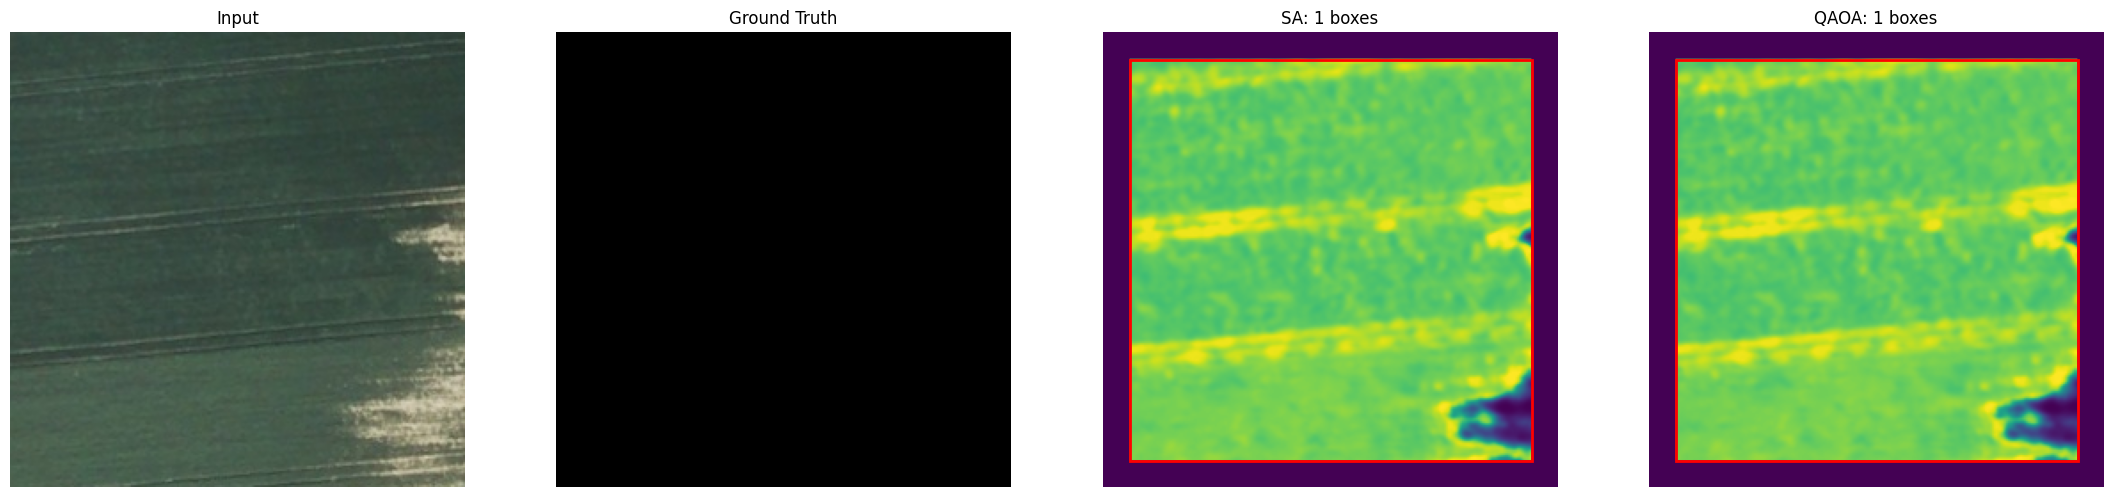

Annealing kept 1 boxes
QAOA      kept 1 boxes


In [ ]:
for i in range(10):
  infere_and_plot()

### final evaluation - metrics

In [32]:
def evaluate_working(model, dataset, device, n_samples=350,
                         threshold=0.5, method="annealing",
                         qaoa_kwargs=None):

    import numpy as np
    import torch

    model.eval()

    total_pixel_acc = 0
    total_iou = 0
    total_dice = 0

    indices = np.random.choice(len(dataset), n_samples, replace=True)

    for idx in indices:
        img, gt_mask = dataset[idx]

        img_tensor = img.unsqueeze(0).to(device)
        img_np = img.permute(1, 2, 0).numpy()

        boxes, pred_mask = run_inference(
            model,
            img_tensor,
            img_np,
            threshold=threshold,
            method=method,
            qaoa_kwargs=qaoa_kwargs
        )

        h, w = pred_mask.shape
        box_mask = np.zeros((h, w), dtype=np.uint8)

        for x1, y1, x2, y2 in boxes:
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
            box_mask[y1:y2, x1:x2] = 1

        gt = gt_mask.squeeze().cpu().numpy()
        gt = (gt > 0.5).astype(np.uint8)

        pixel_acc = (box_mask == gt).mean()

        intersection = np.logical_and(box_mask, gt).sum()
        union = np.logical_or(box_mask, gt).sum()

        iou = intersection / union if union != 0 else 1.0
        dice = (2 * intersection) / (box_mask.sum() + gt.sum()) \
               if (box_mask.sum() + gt.sum()) != 0 else 1.0

        total_pixel_acc += pixel_acc
        total_iou += iou
        total_dice += dice

    n = len(indices)

    print(f"Evaluated on {n} random patches using method = {method}")
    print(f"Pixel Accuracy: {total_pixel_acc / n:.4f}")
    print(f"Mean IoU:        {total_iou / n:.4f}")
    print(f"Mean Dice:       {total_dice / n:.4f}")

In [33]:
evaluate_working(
    model=model,
    dataset=dataset,
    device=device,
    n_samples=350,
    method="qaoa",
    threshold=0.5,
    qaoa_kwargs={"verbose": False}
)

Evaluated on 350 random patches using method = qaoa
Pixel Accuracy: 0.4790
Mean IoU:        0.2409
Mean Dice:       0.2937
